In [85]:
import pandas as pd

In [86]:
df = pd.read_csv(r"C:\Users\hp\Downloads\archive\netflix_titles.csv")

In [87]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [88]:
df.shape

(8807, 12)

In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [90]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [93]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [94]:
df['country'] = df['country'].str.split(',').str[0]

In [95]:
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [96]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not rated')
df['duration_int'] = df['duration_int'].fillna(df['duration_int'].median())

In [97]:
def categorize(row):
    if row['type'] == 'TV Show':
        return 'TV Show'
    elif row['duration_int'] < 60:
        return 'Short'
    elif row['duration_int'] < 120:
        return 'Medium'
    else:
        return 'Long'
df['content_length_category'] = df.apply(categorize, axis=1)

In [98]:
df['primary_genre'] = df['listed_in'].str.split(',').str[0]

In [99]:
df['release_year'] = df['release_year']
df[['release_year']].head()

,release_year
0,2020
1,2021
2,2021
3,2021
4,2021


In [100]:
print(df.shape)
print(df.isnull().sum())
df.info()

(8807, 17)
show_id                     0
type                        0
title                       0
director                    0
cast                        0
country                     0
date_added                 98
release_year                0
rating                      0
duration                    3
listed_in                   0
description                 0
year_added                 98
month_added                98
duration_int                0
content_length_category     0
primary_genre               0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   show_id                  8807 non-null   str           
 1   type                     8807 non-null   str           
 2   title                    8807 non-null   str           
 3   director                 8807 non-null   str           
 4  

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

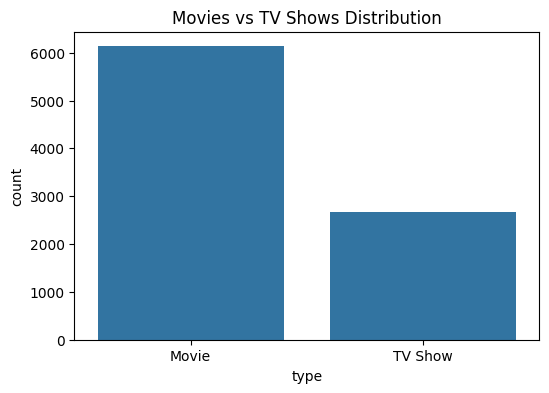

In [102]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Movies vs TV Shows Distribution")
plt.show()

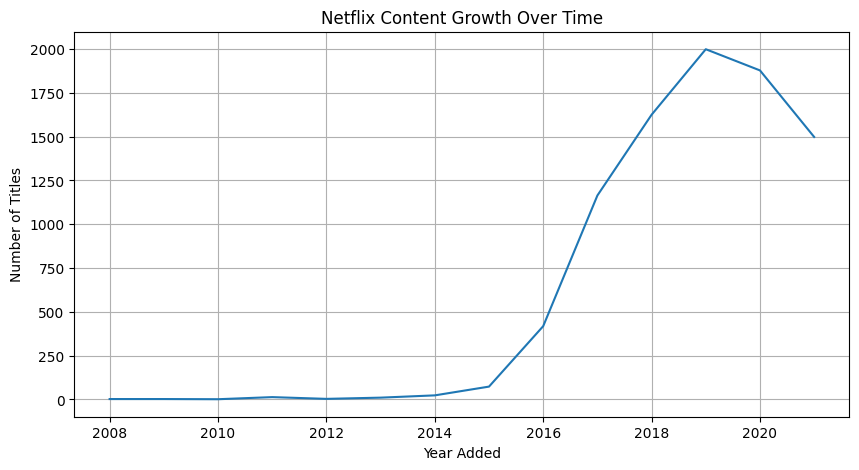

In [103]:
year_growth = df['year_added'].value_counts().sort_index()
plt.figure(figsize=(10,5))
year_growth.plot()
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.grid()
plt.show()

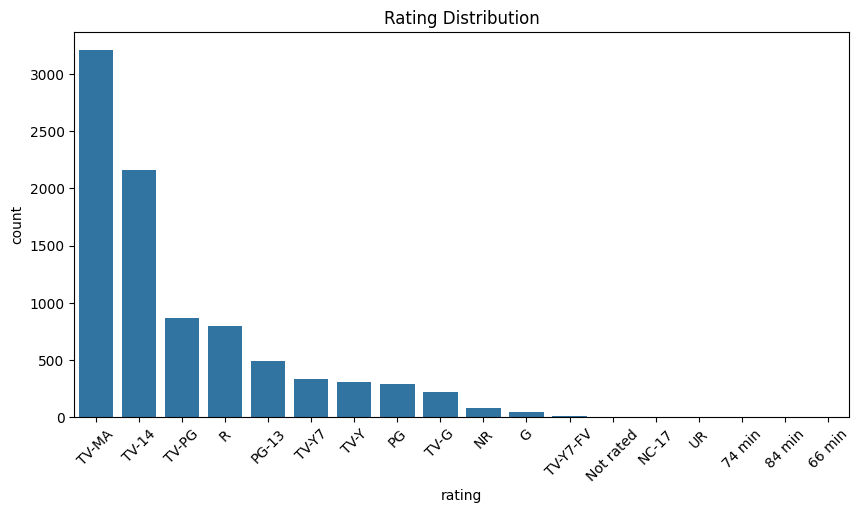

In [104]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Rating Distribution")
plt.show()

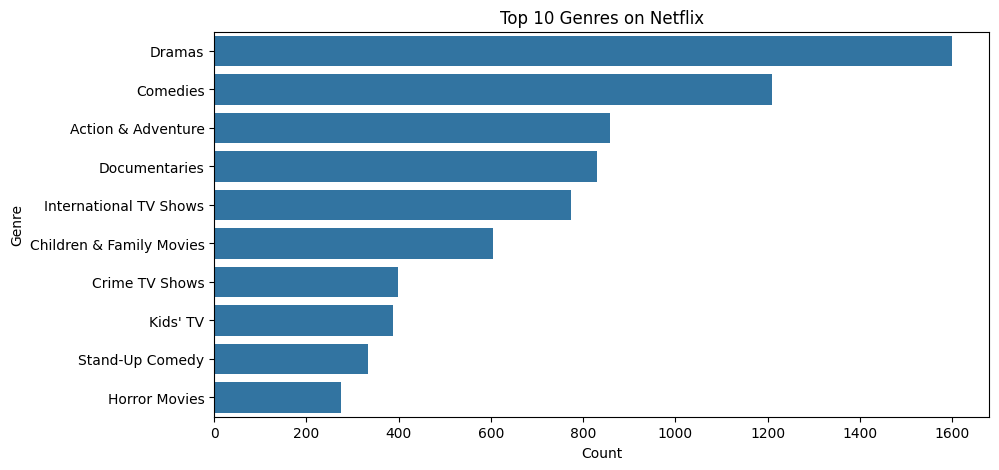

In [105]:
top_genres = df['primary_genre'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [106]:
def content_type(row):
    if row['country'] == 'United States' and row['year_added'] >= 2016:
        return 'Original'
    else:
        return 'Licensed'

df['content_origin'] = df.apply(content_type, axis=1)

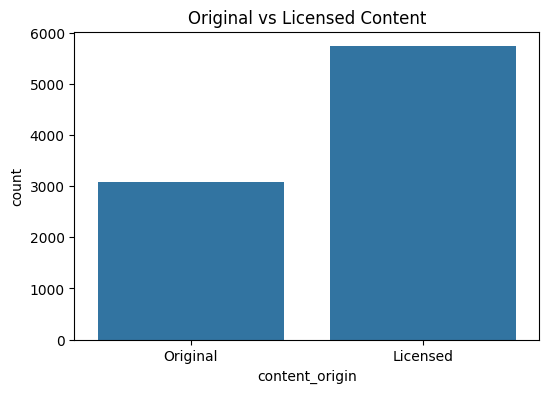

In [107]:
plt.figure(figsize=(6,4)) 
sns.countplot(data=df, x='content_origin') 
plt.title("Original vs Licensed Content") 
plt.show()

In [108]:
cluster_df = df[['duration_int','release_year','primary_genre','rating']]
cluster_df = pd.get_dummies(cluster_df, drop_first=True)

In [109]:
from sklearn.preprocessing import StandardScaler

In [110]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

In [111]:
from sklearn.cluster import KMeans

In [112]:
inertia = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

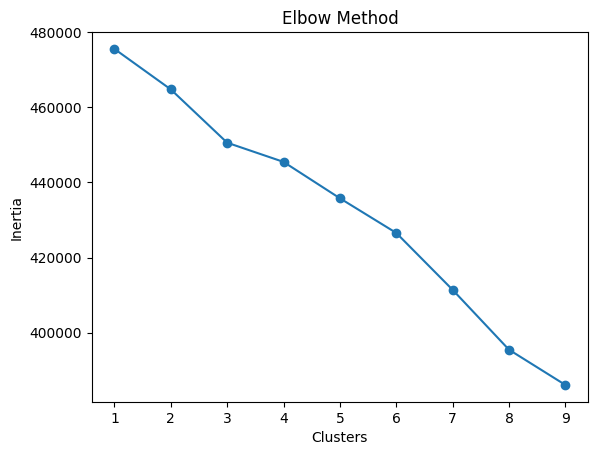

In [113]:
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [114]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

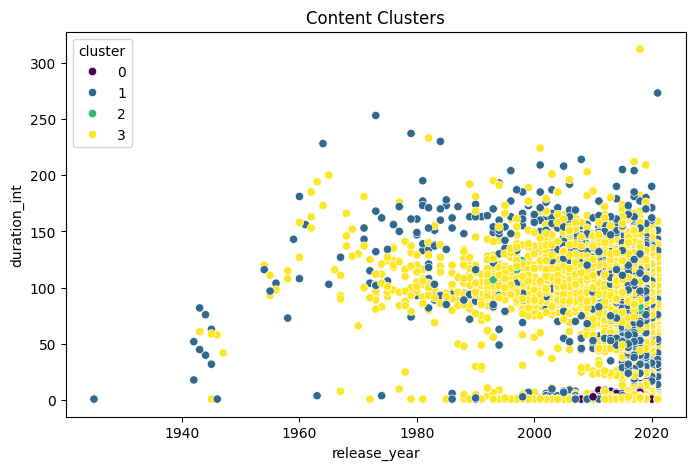

In [115]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['release_year'],
    y=df['duration_int'],
    hue=df['cluster'],
    palette='viridis'
)
plt.title("Content Clusters")
plt.show()

In [116]:
ml_df = df[['type','duration_int','release_year','primary_genre','rating','country']]
ml_df = pd.get_dummies(ml_df, drop_first=True)
X = ml_df.drop('type_TV Show', axis=1)
y = ml_df['type_TV Show']

In [117]:
from sklearn.model_selection import train_test_split

In [118]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [119]:
from sklearn.ensemble import RandomForestClassifier

In [120]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [121]:
from sklearn.metrics import accuracy_score, classification_report

In [122]:
y_pred = model.predict(X_test)

In [123]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

       False       1.00      1.00      1.00      1214
        True       1.00      1.00      1.00       548

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762



In [124]:
from sklearn.metrics import confusion_matrix

In [125]:
cm = confusion_matrix(y_test, y_pred)

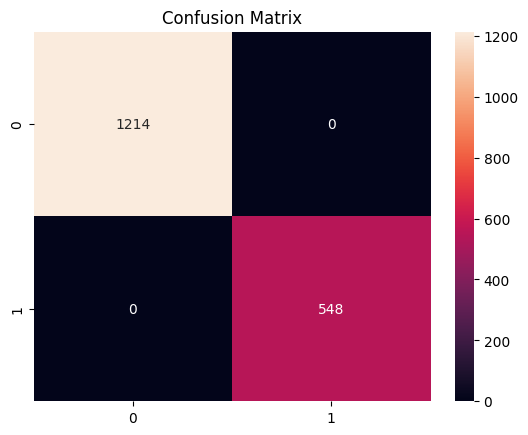

In [126]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [127]:
importance = pd.Series(model.feature_importances_, index=X.columns)

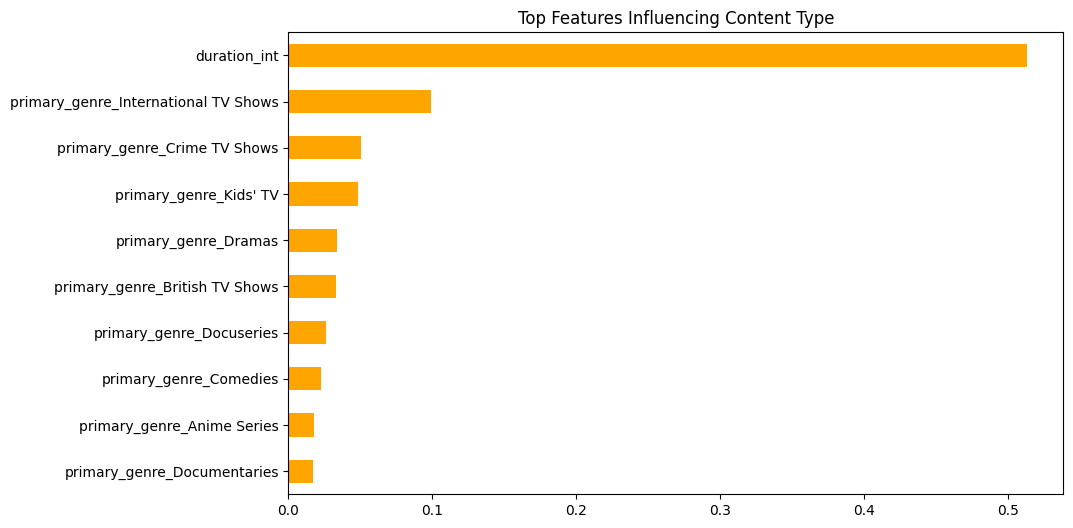

In [128]:
importance.sort_values().tail(10).plot(kind='barh', figsize=(10,6),color = 'orange')
plt.title("Top Features Influencing Content Type")
plt.show()

In [129]:
pd.crosstab(df['country'], df['primary_genre']).head()

primary_genre,Action & Adventure,Anime Features,Anime Series,British TV Shows,Children & Family Movies,Classic & Cult TV,Classic Movies,Comedies,Crime TV Shows,Cult Movies,...,Sports Movies,Stand-Up Comedy,Stand-Up Comedy & Talk Shows,TV Action & Adventure,TV Comedies,TV Dramas,TV Horror,TV Sci-Fi & Fantasy,TV Shows,Thrillers
country,,,,,,,,,,,,,,,,,,,,,
,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Argentina,2,0,0,0,2,1,1,9,7,0,...,0,8,0,0,0,0,0,0,0,0
Australia,8,0,0,2,14,0,3,3,7,0,...,0,3,0,0,3,1,0,0,0,1
Austria,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
Bangladesh,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [130]:
top_countries = df['country'].value_counts().head(5).index
top_genres = df['primary_genre'].value_counts().head(8).index

In [131]:
filtered = df[
    (df['country'].isin(top_countries)) &
    (df['primary_genre'].isin(top_genres))
]

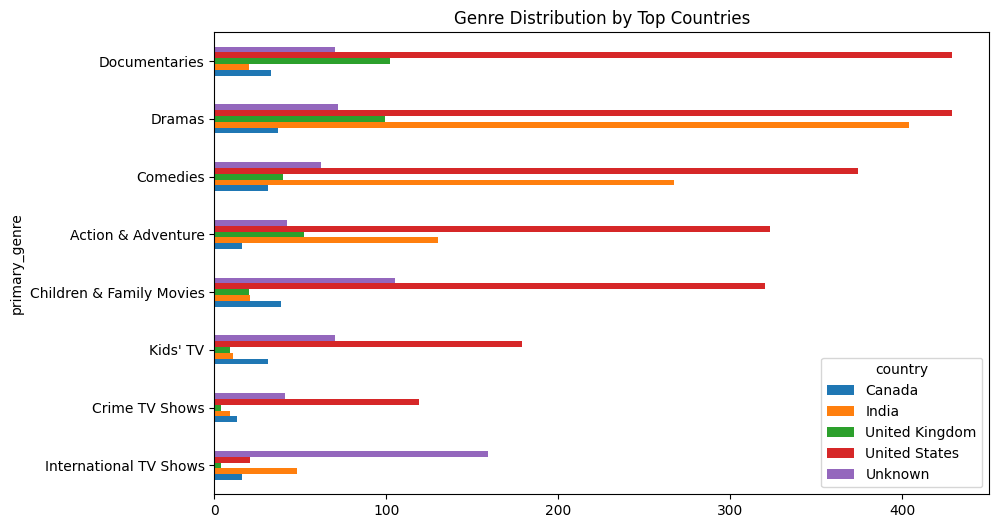

In [132]:
genre_country = genre_country.sort_values(by=top_countries[0], ascending=True)

genre_country.plot(kind='barh', figsize=(10,6))
plt.title("Genre Distribution by Top Countries")
plt.show()